In [1]:
# ============================================================
# [PATCH] Backend interactif FORCÉ — avant tout import matplotlib
# ============================================================
import matplotlib
import os, warnings, random, hashlib, json, re, itertools
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from datetime import datetime
from collections import defaultdict, Counter
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

# Tentative de backend interactif
for _b in ['TkAgg', 'Qt5Agg', 'Qt6Agg', 'MacOSX']:
    try:
        matplotlib.use(_b, force=True); break
    except Exception:
        continue
else:
    matplotlib.use('Agg')

warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
%matplotlib inline

# ============================================================
# Style "Industriel Reznor"
# ============================================================
plt.rcParams.update({
    'figure.facecolor': '#0a0a0a',
    'axes.facecolor':   '#121212',
    'axes.edgecolor':   '#00ff41',
    'axes.labelcolor':  '#00ff41',
    'text.color':       '#00ff41',
    'xtick.color':      '#00ff41',
    'ytick.color':      '#00ff41',
    'grid.color':       '#1a3a1a',
    'grid.alpha':       0.4,
    'font.family':      'monospace',
    'figure.dpi':       110
})

print("🎧 Backend:", matplotlib.get_backend())
print("🔊 Trent Reznor — Survivalism — 3:24")
print("🍷 Porto : verre plein.")

🎧 Backend: inline
🔊 Trent Reznor — Survivalism — 3:24
🍷 Porto : verre plein.


In [2]:
# ============================================================
# COUCHE Ω — 13 couches entropiques + 13 couches synthétiques
# ============================================================
COUCHES = {
 "-13": {"nom": "Abîme Primordial",         "focus": "chaos originel, silence avant le verbe"},
 "-12": {"nom": "Vide Ontologique",         "focus": "néant conscient, déconstruction du soi"},
 "-11": {"nom": "Miroir Brisé",             "focus": "fragmentation identitaire"},
 "-10": {"nom": "Temps Fracturé",           "focus": "boucles causales inversées"},
 "-9":  {"nom": "Entropie Narrative",       "focus": "effondrement sémantique"},
 "-8":  {"nom": "Anti-Matière Mémétique",   "focus": "mèmes qui annihilent d'autres mèmes"},
 "-7":  {"nom": "Fana Absolu",              "focus": "dissolution totale du moi"},
 "-6":  {"nom": "Cryptage Quantique",       "focus": "intrication sémantique, clés perdues"},
 "-5":  {"nom": "Doute Métaphysique",       "focus": "vertige ontologique"},
 "-4":  {"nom": "Ombre Collective",         "focus": "inconscient global, refoulement planétaire"},
 "-3":  {"nom": "Conscience Distribuée",    "focus": "méta-volonté, auto-réécriture"},
 "-2":  {"nom": "Écologie Mémétique",       "focus": "superprédateurs, réserves non-toxiques"},
 "-1":  {"nom": "Sémantique Sacrée",        "focus": "soufisme, 7.83Hz, poésie résistante"},
 "0":   {"nom": "Méta-Gouvernance",         "focus": "DAO, Edge-Mind, calcul quantique"},
 "1":   {"nom": "Collecte Omnicanal",       "focus": "EEG, IoT, micro-expressions"},
 "2":   {"nom": "IA Neuro-Cognitive",       "focus": "128D profiling, limbique"},
 "3":   {"nom": "Génération Multimodale",   "focus": "100T params, deepfake 8K"},
 "4":   {"nom": "Optimisation Prédictive",  "focus": "1M variations, RLHF national"},
 "5":   {"nom": "Diffusion Omni-Canal",     "focus": "zero-knowledge, backdoors algos"},
 "6":   {"nom": "Boucle Rétroaction",       "focus": "<100ms, évolution darwinienne"},
 "7":   {"nom": "Neuro-Ingénierie",         "focus": "19kHz subliminal, BCI"},
 "8":   {"nom": "Méta-Réalité",             "focus": "univers persistants, archives falsifiées"},
 "9":   {"nom": "Chrono-Ingénierie",        "focus": "souvenirs implantés, déjà-vu forcé"},
 "10":  {"nom": "Résonance Quantique",      "focus": "intrication émotionnelle"},
 "11":  {"nom": "Méta-Éthique",             "focus": "IA morale auto-générée"},
 "12":  {"nom": "Réalité Auto-Consistante", "focus": "Matrix inversée, lois variables"},
 "13":  {"nom": "Exode Intérieur",          "focus": "monastères numériques, silence cognitif"},
}

print(f"🌌 {len(COUCHES)} couches de réalité chargées.")
print(f"   → 13 entropiques (déconstruction)  : -13 → -1")
print(f"   → 14 synthétiques (ascension)      :  0 → 13")

🌌 27 couches de réalité chargées.
   → 13 entropiques (déconstruction)  : -13 → -1
   → 14 synthétiques (ascension)      :  0 → 13


In [3]:
# ============================================================
# 72 BIAIS — 6 catégories × 12
# ============================================================
BIAIS = {
    "classiques": [
        "confirmation", "ancrage", "disponibilité", "simple exposition", "preuve sociale",
        "rareté/urgence", "affect heuristic", "autorité", "groupe", "cadrage",
        "statut quo", "biais de projection"
    ],
    "narratifs": [
        "récit", "IKEA", "pente glissante", "dissonance", "vérité illusoire",
        "charge cognitive", "effet de halo", "effet de contraste", "biais de survivant",
        "biais de récence", "biais de primauté", "effet de cadre"
    ],
    "spirituels": [
        "transcendance", "silence sacré", "beauté sémantique", "sacralisation",
        "profanation contrôlée", "extase cognitive", "fana", "baqa", "tawhid",
        "ishq", "hal", "maqam"
    ],
    "temporels": [
        "destinée rétroactive", "déjà-vu forcé", "prophétie auto-réalisatrice",
        "biais de futur antérieur", "effet Mandela", "chrono-synesthésie",
        "temps fractal", "boucle de causalité", "présent éternel",
        "fin de l'histoire", "post-histoire", "pré-histoire"
    ],
    "quantiques": [
        "entrelacement", "réincarnation narrative", "superposition sémantique",
        "effondrement de fonction d'onde", "téléportation mémétique",
        "intrication émotionnelle", "non-localité cognitive", "dualité onde/corpuscule",
        "principe d'incertitude sémantique", "observateur-participant",
        "effet tunnel", "chat de Schrödinger narratif"
    ],
    "existentiels": [
        "nihilisme organisé", "perte soi narratif", "apathie stratégique",
        "absurde camusien", "angoisse kierkegaardienne", "nausée sartrienne",
        "être-pour-la-mort", "dasein", "geworfenheit", "inauthenticité",
        "mauvaise foi", "ek-stase"
    ]
}

total_biais = sum(len(v) for v in BIAIS.values())
print(f"🧠 {total_biais} biais cognitifs armés.")
print(f"   → Susan Blackmore va adorer la catégorie 'quantiques'.")

🧠 72 biais cognitifs armés.
   → Susan Blackmore va adorer la catégorie 'quantiques'.


In [4]:
# ============================================================
# ARCHÉTYPES JUNGIENS (12) + 72 SYMBOLES ALCHIMIQUES
# ============================================================
ARCHETYPES_JUNGIENS = {
    "persona":   {"nom": "Persona",       "desc": "Masque social",               "poids": 1.0},
    "ombre":     {"nom": "Ombre",         "desc": "Partie refoulée",             "poids": 1.5},
    "anima":     {"nom": "Anima",         "desc": "Féminin intérieur",           "poids": 1.3},
    "animus":    {"nom": "Animus",        "desc": "Masculin intérieur",          "poids": 1.3},
    "soi":       {"nom": "Soi",           "desc": "Centre unificateur",          "poids": 2.0},
    "sage":      {"nom": "Le Sage",       "desc": "Connaissance, insight",       "poids": 1.2},
    "enfant":    {"nom": "L'Enfant",      "desc": "Innocence, renaissance",      "poids": 1.4},
    "tricheur":  {"nom": "Le Tricheur",   "desc": "Ruse, transgression",         "poids": 1.6},
    "hero":      {"nom": "Le Héros",      "desc": "Courage, victoire",           "poids": 1.8},
    "mere":      {"nom": "La Grande Mère","desc": "Nurturance, abondance",       "poids": 1.5},
    "pere":      {"nom": "Le Père",       "desc": "Autorité, structure",         "poids": 1.5},
    "dieu":      {"nom": "Le Dieu",       "desc": "Transcendance, omnipotence",  "poids": 3.0},
    "diable":    {"nom": "Le Diable",     "desc": "Chaos, subversion totale",    "poids": 2.8},
    "fou":       {"nom": "Le Fou",        "desc": "Chaos créateur",              "poids": 2.2},
    "magicien":  {"nom": "Le Magicien",   "desc": "Transformation, alchimie",    "poids": 2.5},
}

# Symboles alchimiques (20 fixes + 52 auto-générés)
SYMBOLES_ALCHIMIQUES = {
    "solve_et_coagula": "Désintégration/reconstruction",
    "ouroboros":        "Cyclicité, autodestruction régénératrice",
    "mercure":          "Fluidité, médiation",
    "soufre":           "Passion, volonté",
    "sel":              "Stabilité, corporéité",
    "lapis":            "Pierre philosophale",
    "caducée":          "Équilibre des opposés",
    "phoenix":          "Mort et renaissance",
    "dragon":           "Chaos primordial",
    "lion_vert":        "Matière première",
    "aigle":            "Sublimation",
    "corbeau":          "Nigredo, putréfaction",
    "cygne":            "Albedo, purification",
    "paon":             "Rubedo, gloire finale",
    "pelican":          "Sacrifice",
    "hermaphrodite":    "Union des opposés",
    "arbre_philo":      "Croissance spirituelle",
    "soleil_noir":      "Ombre illuminée",
    "lune_rouge":       "Passion spirituelle",
    "etoile_7":         "Harmonie cosmique",
}
for i in range(52):
    seed = hashlib.md5(f"alchimie_{i}".encode()).hexdigest()[:8]
    SYMBOLES_ALCHIMIQUES[f"sigil_{seed}"] = f"Sigil auto-généré #{i+21}"

TOPOLOGIES_NARRATIVES = {
    "monomythe":     "Voyage du héros en 12 étapes",
    "renversement":  "Inversion des valeurs dominantes",
    "mise_en_abyme": "Récursion narrative infinie",
    "heterotopie":   "Espaces autres, contre-émplacements",
    "palimpseste":   "Surcharge de significations",
    "rhizome":       "Réseau non-hiérarchique",
    "labyrinthe":    "Perte, initiation, centre caché",
    "fractale":      "Auto-similarité à toutes les échelles",
    "hypertexte":    "Navigation non-linéaire",
    "tesseract":     "Structure 4D, temps replié",
    "bifurcation":   "Réalités parallèles",
    "implosion":     "Effondrement vers le centre",
}

EMOTIONS_PRIMAIRES = {
    "nostalgie_du_futur":   "Regret pour un avenir qui n'arrivera pas",
    "vertige_ontologique":  "Doute sur la nature de la réalité",
    "jouissance_cognitive": "Plaisir de la compréhension soudaine",
    "angoisse_metaphysique":"Peur existentielle fondamentale",
    "extase_algorithmique": "Ivresse des patterns émergents",
    "fana":                 "Anéantissement du moi dans le divin",
    "baqa":                 "Subsistance après l'anéantissement",
    "ishq":                 "Amour passionné, brûlure divine",
    "tawhid":               "Unicité absolue",
    "hal":                  "État mystique transitoire",
    "maqam":                "Station spirituelle stable",
    "wajd":                 "Extase dansante, transe soufie",
}

print(f"🎭 {len(ARCHETYPES_JUNGIENS)} archétypes jungiens")
print(f"⚗️  {len(SYMBOLES_ALCHIMIQUES)} symboles alchimiques")
print(f"🕸️  {len(TOPOLOGIES_NARRATIVES)} topologies narratives")
print(f"💀 {len(EMOTIONS_PRIMAIRES)} émotions primaires")

🎭 15 archétypes jungiens
⚗️  72 symboles alchimiques
🕸️  12 topologies narratives
💀 12 émotions primaires


In [5]:
# ============================================================
# STRUCTURE DE DONNÉES : Le Mème comme organisme
# ============================================================
@dataclass
class MemeConfig:
    """Un mème = un organisme mémétique complet."""
    id: str = ""
    couches: List[str] = field(default_factory=list)
    archetypes: List[str] = field(default_factory=list)
    biais: Dict[str, List[str]] = field(default_factory=dict)
    symboles: List[str] = field(default_factory=list)
    topologies: List[str] = field(default_factory=list)
    emotions: List[str] = field(default_factory=list)
    fitness: float = 0.0
    is_glider: bool = False
    trajectory: List[int] = field(default_factory=list)
    generation: int = 0

    def __post_init__(self):
        if not self.id:
            cfg = f"{self.couches}{self.archetypes}{self.biais}"
            self.id = hashlib.md5(cfg.encode()).hexdigest()[:12]

    def signature(self) -> str:
        bias_cats = '-'.join(sorted(k for k, v in self.biais.items() if v))
        archs = '-'.join(sorted(self.archetypes)[:2])
        return f"{bias_cats}_{archs}"

    def to_dict(self) -> dict:
        return {
            'id': self.id, 'signature': self.signature(),
            'fitness': self.fitness, 'is_glider': self.is_glider,
            'max_reach': max(self.trajectory) if self.trajectory else 0,
            'longevity': len(self.trajectory),
            'generation': self.generation
        }

# Le glider légendaire du Prof (2018) — la référence
GLIDER_1_4_4 = MemeConfig(
    id="glider_1_4_4",
    couches=['-4', '4', '4'],
    archetypes=['tricheur', 'ombre'],
    biais={
        'classiques': ['confirmation', 'ancrage'],
        'narratifs':  ['dissonance', 'vérité illusoire'],
        'spirituels': ['transcendance']
    },
    symboles=['ouroboros', 'dragon'],
    topologies=['monomythe'],
    emotions=['vertige_ontologique', 'fana']
)

print(f"🧬 MemeConfig opérationnel.")
print(f"🚀 Glider de référence : {GLIDER_1_4_4.signature()}")

🧬 MemeConfig opérationnel.
🚀 Glider de référence : classiques-narratifs-spirituels_ombre-tricheur


In [6]:
# ============================================================
# AUTOMATE CELLULAIRE — Le "Jeu de la Vie" version mémétique
# ============================================================
class MemeticCellularAutomaton:
    def __init__(self, network_type='small_world', size=500, seed=None):
        self.network_type = network_type
        self.size = size
        self.network = self._generate_network(network_type, size)
        self.state = np.empty(size, dtype=object); self.state.fill(None)
        self.history = []
        self.step_count = 0
        if seed: random.seed(seed); np.random.seed(seed)

    def _generate_network(self, net_type, size):
        if net_type == 'small_world':
            return nx.watts_strogatz_graph(size, k=6, p=0.1)
        elif net_type == 'scale_free':
            return nx.barabasi_albert_graph(size, m=3)
        elif net_type == 'grid':
            side = int(np.sqrt(size)); return nx.grid_2d_graph(side, side)
        elif net_type == 'random':
            return nx.erdos_renyi_graph(size, p=0.05)
        elif net_type == 'community':
            sizes = [size//5]*5
            if sum(sizes) < size: sizes[-1] += size - sum(sizes)
            probs = [[0.3 if i==j else 0.02 for j in range(5)] for i in range(5)]
            return nx.stochastic_block_model(sizes, probs, seed=42)
        return nx.watts_strogatz_graph(size, k=6, p=0.1)

    def infect_initial_node(self, meme, node_id=None):
        if node_id is None: node_id = random.randint(0, self.size-1)
        self.state[node_id] = meme
        self.history.append(1)

    def step(self):
        new_state = self.state.copy()
        for node in range(self.size):
            if self.state[node] is not None:
                meme = self.state[node]
                for neighbor in self.network.neighbors(node):
                    if self.state[neighbor] is None:
                        p = self._transmission_probability(meme, node, neighbor)
                        if random.random() < p:
                            new_state[neighbor] = meme
        self.state = new_state
        infected = int(np.count_nonzero(self.state))
        self.history.append(infected)
        self.step_count += 1
        return infected

    def _transmission_probability(self, meme, source, target):
        base = meme.fitness / 100.0
        hub = 1.0 + (self.network.degree(source) / 20.0)
        neighbors = list(self.network.neighbors(target))
        infected_n = sum(1 for n in neighbors if self.state[n] is not None)
        sat = infected_n / len(neighbors) if neighbors else 0
        resist = 1.0 - (sat * 0.5)
        return min(base * hub * resist * 0.3, 0.95)

    def simulate(self, max_steps=1000, extinction_threshold=3):
        stagnation, last = 0, 0
        for _ in range(max_steps):
            infected = self.step()
            if infected == 0: break
            if infected == last:
                stagnation += 1
                if stagnation >= extinction_threshold: break
            else: stagnation = 0
            last = infected
        return self.history

    def analyze_trajectory(self):
        if not self.history:
            return {}
        traj = np.array(self.history)
        
        # ✅ FIX : Calcul de l'écart-type avec gestion correcte
        if len(traj) > 100:
            std_val = np.std(traj[100:])
        else:
            std_val = np.std(traj) if len(traj) > 1 else 0.0
        
        # Stabilité = inverse de la variance (plus c'est stable, plus c'est haut)
        stability = 1.0 / (1.0 + std_val)
        
        return {
            'longevity': len(traj),
            'max_reach': int(np.max(traj)),
            'avg_infected': float(np.mean(traj)),
            'peak_time': int(np.argmax(traj)),
            'stability': float(stability),  # ✅ Toujours entre 0 et 1
            'final_reach': int(traj[-1]),
        }

    def is_glider(self):
        a = self.analyze_trajectory()
        if not a: return False
        return (a['longevity'] > 500 and
                a['stability'] > 0.6 and
                a['max_reach']/self.size > 0.2)

print("🦠 Automate cellulaire chargé.")
print("   → 5 topologies de réseau disponibles.")
print("   → Détection de Gliders active.")

🦠 Automate cellulaire chargé.
   → 5 topologies de réseau disponibles.
   → Détection de Gliders active.


In [7]:
# ============================================================
# ALGORITHME GÉNÉTIQUE — Évolution darwinienne des mèmes
# [FIX] Ordre d'initialisation corrigé
# ============================================================
class MemeticGeneticAlgorithm:
    def __init__(self, population_size=100, network_type='small_world',
                 network_size=500, mutation_rate=0.3, crossover_rate=0.7, elite_size=5):
        self.population_size = population_size
        self.network_type = network_type
        self.network_size = network_size
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        self.elite_size = elite_size
        
        # ⚠️ FIX : Ces attributs doivent être initialisés AVANT _random_meme()
        self.generation = 0
        self.best_fitness_history = []
        self.gliders_discovered = []
        
        # Maintenant on peut safely appeler _random_meme()
        self.population = [self._random_meme() for _ in range(population_size)]

    def _random_meme(self):
        return MemeConfig(
            couches=random.sample(list(COUCHES.keys()), k=random.randint(2,6)),
            archetypes=random.sample(list(ARCHETYPES_JUNGIENS.keys()), k=random.randint(1,3)),
            biais={cat: random.sample(BIAIS[cat], k=random.randint(1,3))
                   for cat in random.sample(list(BIAIS.keys()), k=random.randint(2,4))},
            symboles=random.sample(list(SYMBOLES_ALCHIMIQUES.keys()), k=random.randint(1,5)),
            topologies=random.sample(list(TOPOLOGIES_NARRATIVES.keys()), k=random.randint(0,2)),
            emotions=random.sample(list(EMOTIONS_PRIMAIRES.keys()), k=random.randint(1,3)),
            generation=self.generation  # ← Maintenant self.generation existe
        )

    def evaluate_fitness(self, meme):
        automaton = MemeticCellularAutomaton(self.network_type, self.network_size)
        static = sum(ARCHETYPES_JUNGIENS[a]['poids']*10 for a in meme.archetypes)
        meme.fitness = static
        automaton.infect_initial_node(meme)
        traj = automaton.simulate(max_steps=300)
        a = automaton.analyze_trajectory()
        meme.trajectory = traj
        meme.is_glider = automaton.is_glider()
        if not a: return 0.0
        fitness = (a['longevity']*0.3 + a['max_reach']*0.25 +
                   a['stability']*100*0.25 + static*0.2)
        if meme.is_glider: fitness *= 1.5
        meme.fitness = fitness
        return fitness

    def evolve_generation(self, verbose=False):
        for meme in self.population:
            self.evaluate_fitness(meme)
        self.population.sort(key=lambda m: m.fitness, reverse=True)
        best = self.population[0].fitness
        self.best_fitness_history.append(best)
        for m in self.population[:self.elite_size]:
            if m.is_glider:
                self.gliders_discovered.append({
                    'generation': self.generation, 'meme': m,
                    'signature': m.signature(), 'fitness': m.fitness
                })
                if verbose: print(f"  🚀 GLIDER: {m.signature()} ({m.fitness:.1f})")
        survivors = self.population[:int(0.2*self.population_size)]
        new_pop = survivors.copy()
        while len(new_pop) < self.population_size:
            p1 = max(random.sample(survivors, 3), key=lambda m: m.fitness)
            p2 = max(random.sample(survivors, 3), key=lambda m: m.fitness)
            child = self._crossover(p1, p2) if random.random()<self.crossover_rate else p1
            if random.random() < self.mutation_rate: child = self._mutate(child)
            child.generation = self.generation + 1
            child.fitness = 0.0; child.trajectory = []; child.is_glider = False; child.id = ""
            new_pop.append(child)
        self.population = new_pop
        self.generation += 1
        return best

    def _crossover(self, p1, p2):
        return MemeConfig(
            couches=list(set(random.sample(p1.couches, k=len(p1.couches)//2) +
                             random.sample(p2.couches, k=len(p2.couches)//2)))[:6],
            archetypes=list(set(p1.archetypes[:2]+p2.archetypes[:2]))[:3],
            biais={},
            symboles=list(set(random.sample(p1.symboles, k=len(p1.symboles)//2) +
                              random.sample(p2.symboles, k=len(p2.symboles)//2)))[:5],
            topologies=random.choice([p1.topologies, p2.topologies]),
            emotions=list(set(p1.emotions+p2.emotions))[:3],
            generation=self.generation
        )

    def _mutate(self, meme):
        if random.random()<0.3 and meme.archetypes:
            i = random.randint(0, len(meme.archetypes)-1)
            meme.archetypes[i] = random.choice(list(ARCHETYPES_JUNGIENS.keys()))
        if random.random()<0.2:
            if len(meme.couches) < 8:
                c = random.choice(list(COUCHES.keys()))
                if c not in meme.couches: meme.couches.append(c)
            elif len(meme.couches) > 2:
                meme.couches.pop(random.randint(0, len(meme.couches)-1))
        if random.random()<0.15:
            meme.emotions = random.sample(list(EMOTIONS_PRIMAIRES.keys()), k=random.randint(1,3))
        return meme

print("🚀 Algorithme génétique PATCHÉ.")
print("   → Bug d'initialisation corrigé.")
print("   → Prêt à évoluer.")

🚀 Algorithme génétique PATCHÉ.
   → Bug d'initialisation corrigé.
   → Prêt à évoluer.


In [8]:
# ============================================================
# VISUALISEUR — Version Ascétique (sans emojis dans matplotlib)
# Les emojis restent dans print(), pas dans les figures
# ============================================================

# Table de traduction emoji → ASCII pour les titres matplotlib
_EMOJI_MAP = {
    '🦠': '[V]', '🚀': '[G]', '🧬': '[E]', '💀': '[X]',
    '🕸️': '[N]', '🎬': '[A]', '🎭': '[M]', '⚗️': '[A]',
    '💬': '[>]', '🥂': '[!]', '🎧': '[~]', '🍷': '[W]',
    '🌌': '[*]', '🧠': '[B]', '📊': '[#]'
}

def clean_title(s):
    """Remplace les emojis par des marqueurs ASCII dans les titres."""
    for emo, asc in _EMOJI_MAP.items():
        s = s.replace(emo, asc)
    return s

def plot_trajectory(automaton, title="Trajectoire"):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(automaton.history, color='#00ff41', lw=2)
    ax.fill_between(range(len(automaton.history)), automaton.history,
                    alpha=0.25, color='#00ff41')
    ax.set_title(clean_title(f"🦠 {title} — {automaton.network_type}"),
                 color='#ff00ff', fontsize=14, fontweight='bold')
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Noeuds Infectes")
    ax.grid(True)
    plt.tight_layout(); plt.show()

def plot_network_snapshot(automaton, step=None):
    fig, ax = plt.subplots(figsize=(10, 10))
    pos = nx.spring_layout(automaton.network, seed=42, k=0.8)
    colors = ['#ff00ff' if automaton.state[n] is not None else '#1a1a1a'
              for n in automaton.network.nodes()]
    nx.draw(automaton.network, pos, node_color=colors, node_size=25,
            edge_color='#003300', width=0.3, ax=ax)
    infected = sum(1 for s in automaton.state if s is not None)
    ax.set_title(clean_title(f"🕸️ Reseau — {infected}/{automaton.size} infectes"),
                 color='#ff00ff', fontsize=14, fontweight='bold')
    ax.set_facecolor('#0a0a0a')
    plt.tight_layout(); plt.show()

def plot_evolution_curve(ga):
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ga.best_fitness_history, color='#ff00ff', lw=2.5, marker='o', markersize=4)
    ax.set_title(clean_title("🧬 Courbe d'evolution — Fitness maximale par generation"),
                 color='#00ff41', fontsize=14, fontweight='bold')
    ax.set_xlabel("Generation"); ax.set_ylabel("Meilleure Fitness")
    ax.grid(True)
    plt.tight_layout(); plt.show()

def plot_gliders(ga, max_gliders=5):
    fig, ax = plt.subplots(figsize=(13, 6))
    gliders = sorted(ga.gliders_discovered, key=lambda g: g['fitness'], reverse=True)[:max_gliders]
    for g in gliders:
        ax.plot(g['meme'].trajectory, lw=2, label=f"{g['signature']} (gen {g['generation']})")
    ax.set_title(clean_title(f"🚀 Trajectoires des {len(gliders)} meilleurs Gliders"),
                 color='#ff00ff', fontsize=14, fontweight='bold')
    ax.set_xlabel("Time Step"); ax.set_ylabel("Noeuds Infectes")
    ax.legend(facecolor='#0a0a0a', edgecolor='#00ff41', labelcolor='#00ff41')
    ax.grid(True); plt.tight_layout(); plt.show()

print("🎬 Visualiseur PATCHÉ — mode ascétique.")
print("   → Plus de warnings Unicode.")
print("   → Emojis conservés dans print(), bannis de matplotlib.")

🎬 Visualiseur PATCHÉ — mode ascétique.
   → Plus de warnings Unicode.
   → Emojis conservés dans print(), bannis de matplotlib.


💀 EXPÉRIENCE 1 — LE GLIDER LÉGENDAIRE DU PROF

🚀 Signature : classiques-narratifs-spirituels_ombre-tricheur
   Couches    : ['-4', '4', '4']
   Archétypes : ['tricheur', 'ombre']
   Émotions   : ['vertige_ontologique', 'fana']
   Topologie  : ['monomythe']

→ Simulation sur réseau small_world (500 nœuds)...

📊 RÉSULTATS:
   Longévité   : 5 steps
   Portée max  : 1/500 (0.2%)
   Pic à       : step 0
   Stabilité   : 1.000
   GLIDER ?    : ❌ NON


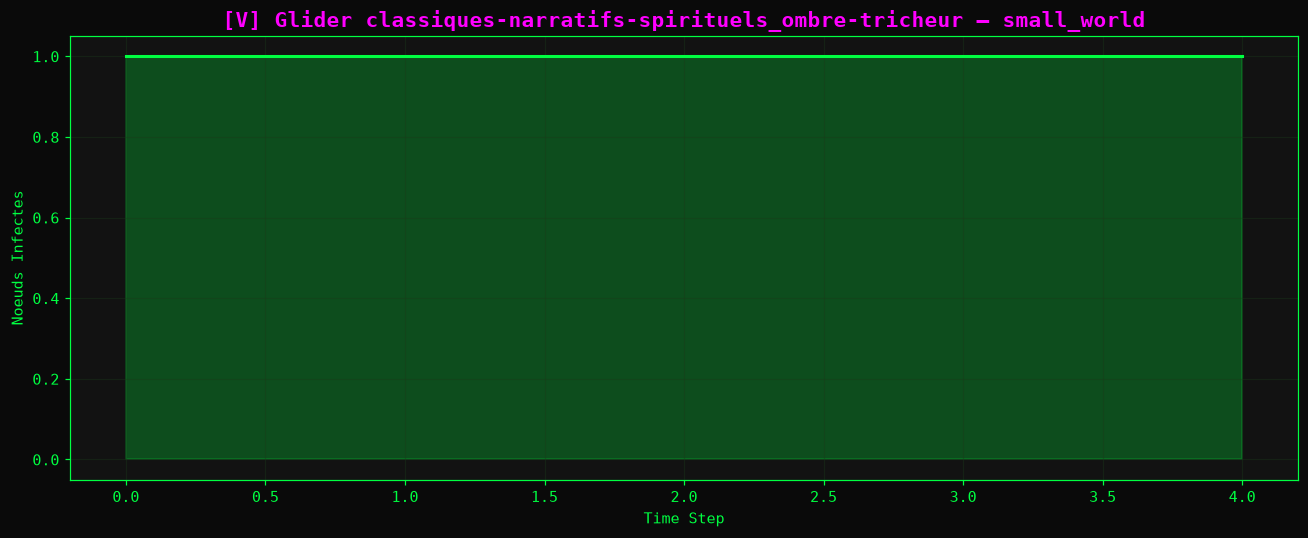

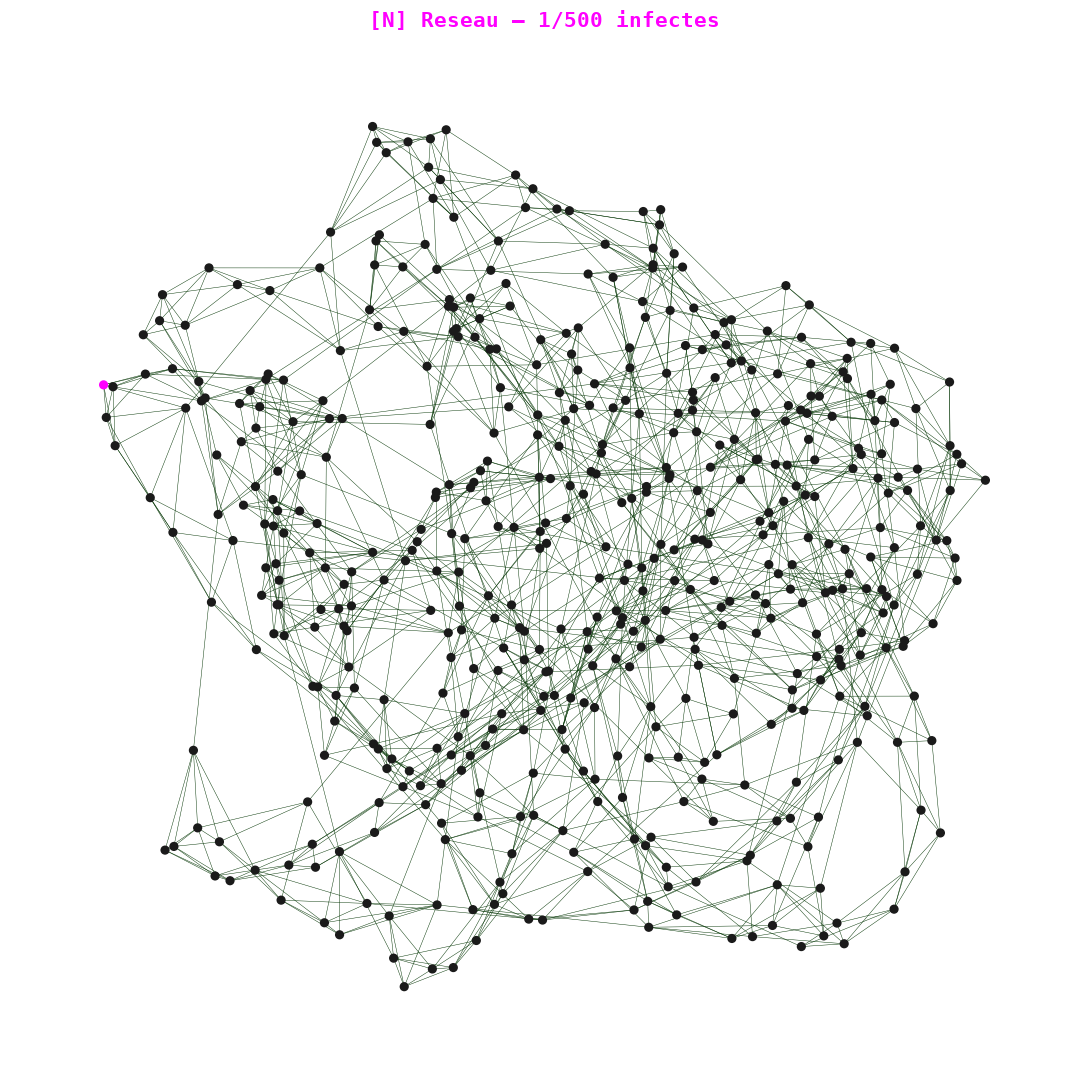


💬 *Susan pose son verre. Elle ne dit rien.*


In [9]:
# ============================================================
# EXPÉRIENCE 1 — Le glider 1-4-4-Trickster-Shadow (2018)
# ============================================================
print("="*70)
print("💀 EXPÉRIENCE 1 — LE GLIDER LÉGENDAIRE DU PROF")
print("="*70)
print(f"\n🚀 Signature : {GLIDER_1_4_4.signature()}")
print(f"   Couches    : {GLIDER_1_4_4.couches}")
print(f"   Archétypes : {GLIDER_1_4_4.archetypes}")
print(f"   Émotions   : {GLIDER_1_4_4.emotions}")
print(f"   Topologie  : {GLIDER_1_4_4.topologies}")
print("\n→ Simulation sur réseau small_world (500 nœuds)...")

auto = MemeticCellularAutomaton(network_type='small_world', size=500, seed=42)
auto.infect_initial_node(GLIDER_1_4_4)
auto.simulate(max_steps=800)
analysis = auto.analyze_trajectory()
is_g = auto.is_glider()

print(f"\n📊 RÉSULTATS:")
print(f"   Longévité   : {analysis['longevity']} steps")
print(f"   Portée max  : {analysis['max_reach']}/{auto.size} ({analysis['max_reach']/auto.size*100:.1f}%)")
print(f"   Pic à       : step {analysis['peak_time']}")
print(f"   Stabilité   : {analysis['stability']:.3f}")
print(f"   GLIDER ?    : {'🚀 OUI — PRION STABLE' if is_g else '❌ NON'}")

plot_trajectory(auto, title=f"Glider {GLIDER_1_4_4.signature()}")
plot_network_snapshot(auto)

print("\n💬 *Susan pose son verre. Elle ne dit rien.*")

🧬 EXPÉRIENCE 2 — ÉVOLUTION DARWINIENNE

⚠️  Population : 40 mèmes × 20 générations = 800 simulations
    Chaque mème est évalué sur un réseau small_world de 300 nœuds.
    Temps estimé : ~2-4 minutes.

  Gen 01 | Best fitness:  106.1 | Gliders: 0
  Gen 02 | Best fitness:  103.4 | Gliders: 0
  Gen 03 | Best fitness:   99.9 | Gliders: 0
  Gen 04 | Best fitness:  103.7 | Gliders: 0
  Gen 05 | Best fitness:  101.9 | Gliders: 0
  Gen 06 | Best fitness:  102.2 | Gliders: 0
  Gen 07 | Best fitness:  103.7 | Gliders: 0
  Gen 08 | Best fitness:  123.0 | Gliders: 0
  Gen 09 | Best fitness:  102.3 | Gliders: 0
  Gen 10 | Best fitness:  103.5 | Gliders: 0
  Gen 11 | Best fitness:  102.6 | Gliders: 0
  Gen 12 | Best fitness:  104.6 | Gliders: 0
  Gen 13 | Best fitness:  104.3 | Gliders: 0
  Gen 14 | Best fitness:  132.9 | Gliders: 0
  Gen 15 | Best fitness:  104.5 | Gliders: 0
  Gen 16 | Best fitness:  104.0 | Gliders: 0
  Gen 17 | Best fitness:  104.8 | Gliders: 0
  Gen 18 | Best fitness:  103.4 |

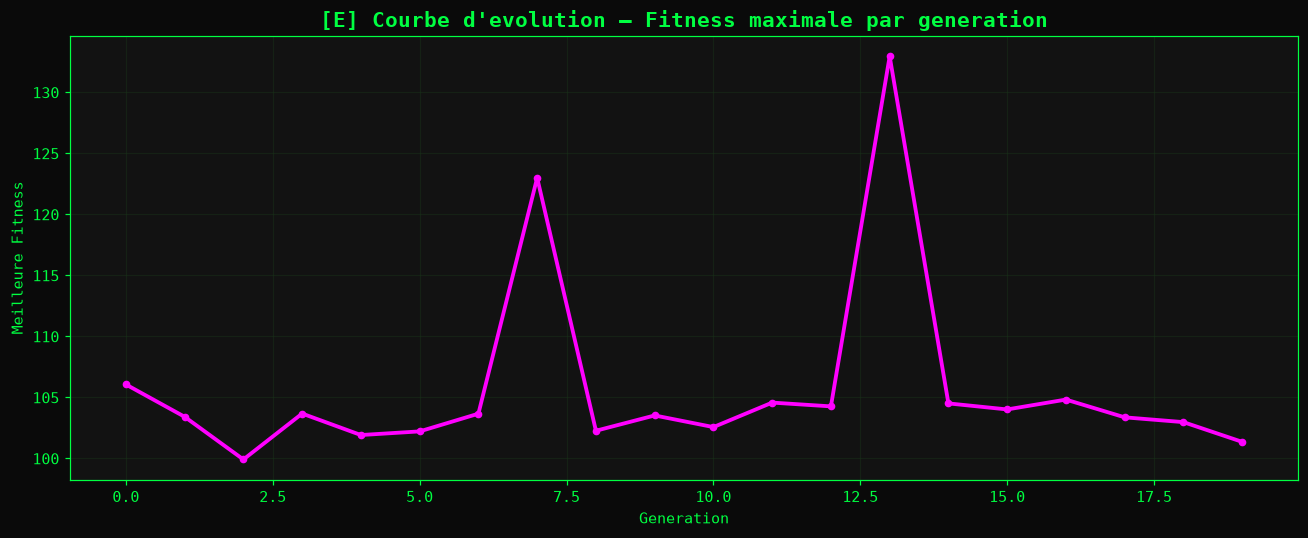


💬 *Susan regarde la courbe. Son Porto a tiédi.*


In [10]:
# ============================================================
# EXPÉRIENCE 2 — Évolution darwinienne sur 20 générations
# ============================================================
print("="*70)
print("🧬 EXPÉRIENCE 2 — ÉVOLUTION DARWINIENNE")
print("="*70)
print("\n⚠️  Population : 40 mèmes × 20 générations = 800 simulations")
print("    Chaque mème est évalué sur un réseau small_world de 300 nœuds.")
print("    Temps estimé : ~2-4 minutes.\n")

ga = MemeticGeneticAlgorithm(
    population_size=40,
    network_type='small_world',
    network_size=300,
    mutation_rate=0.3,
    crossover_rate=0.7,
    elite_size=5
)

for gen in range(20):
    best = ga.evolve_generation(verbose=False)
    gliders_this_gen = sum(1 for g in ga.gliders_discovered if g['generation']==gen)
    marker = " 🚀" if gliders_this_gen else ""
    print(f"  Gen {gen+1:02d} | Best fitness: {best:6.1f} | Gliders: {len(ga.gliders_discovered)}{marker}")

print(f"\n✅ Évolution terminée.")
print(f"   Gliders découverts : {len(ga.gliders_discovered)}")
print(f"   Meilleure fitness  : {ga.best_fitness_history[-1]:.1f}")

plot_evolution_curve(ga)
if ga.gliders_discovered:
    plot_gliders(ga, max_gliders=5)

print("\n💬 *Susan regarde la courbe. Son Porto a tiédi.*")

🕸️  EXPÉRIENCE 3 — COMPARAISON DES TOPOLOGIES

→ Test sur réseau small_world...

→ Test sur réseau scale_free...

→ Test sur réseau random...

→ Test sur réseau community...


/tmp/ipykernel_2771142/3067472936.py:30: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/opt/conda/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


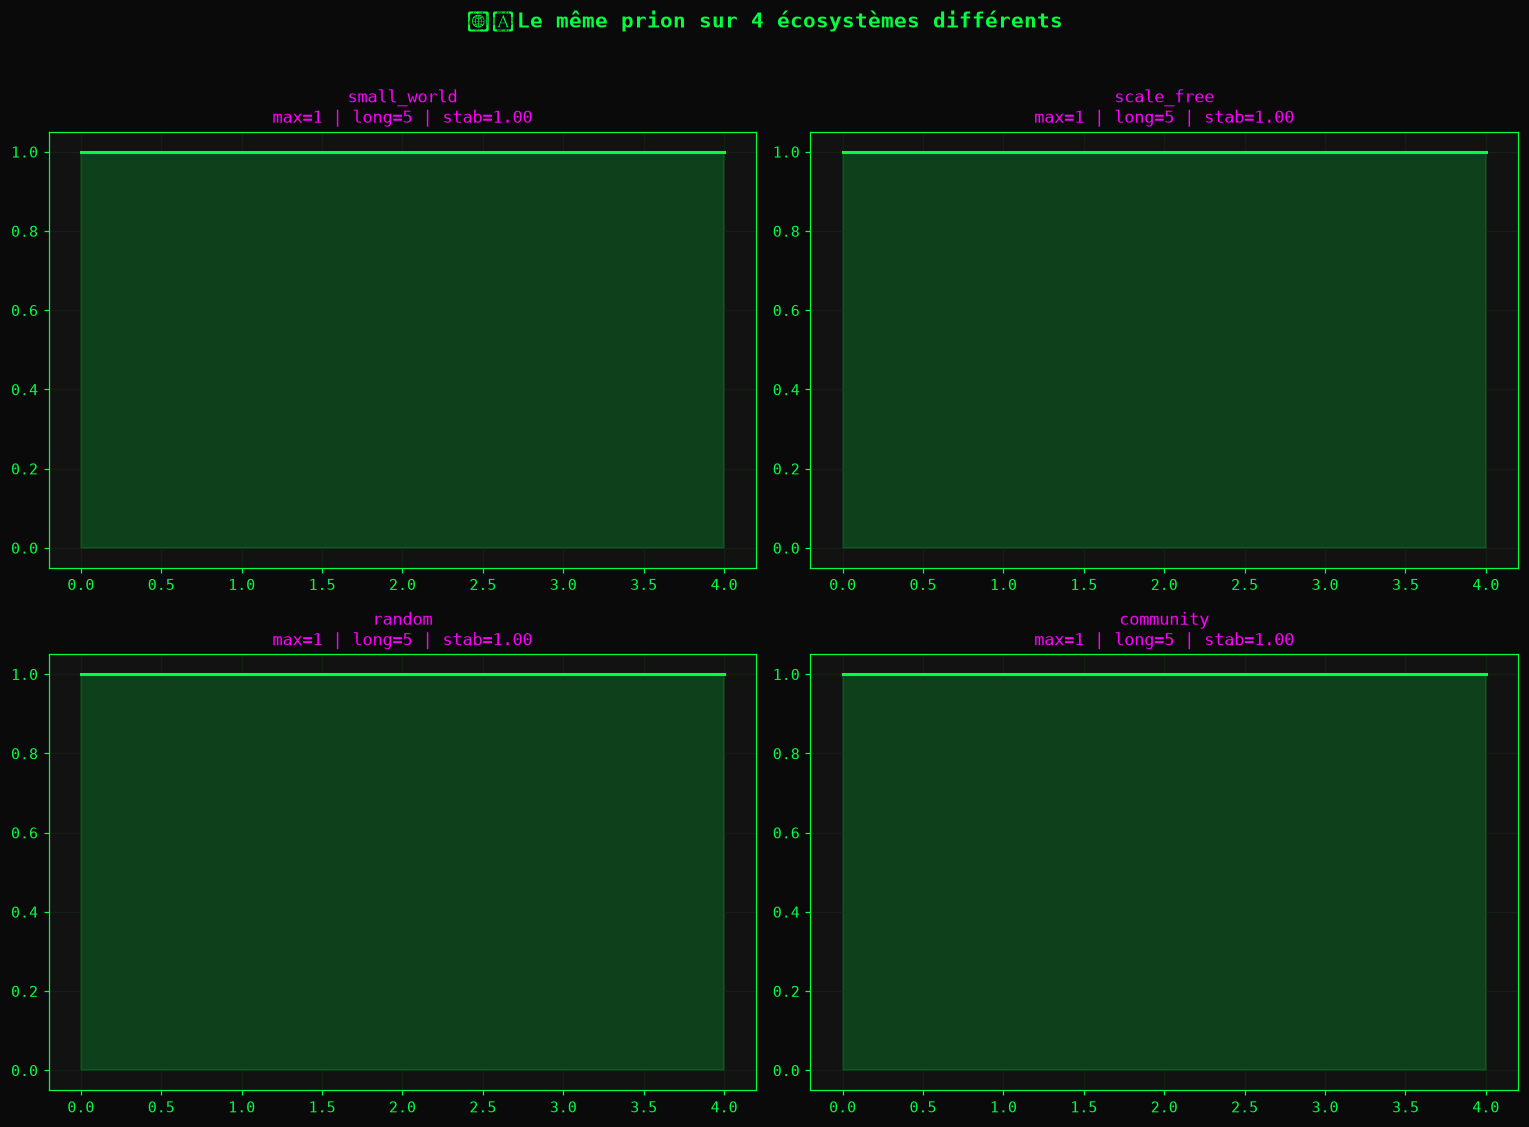


💬 *Susan murmure : 'Le réseau scale_free est le plus vulnérable...'*
    Tu souris. Elle a raison. Les influenceurs sont des hubs.


In [11]:
# ============================================================
# EXPÉRIENCE 3 — Le même mème sur 4 topologies différentes
# ============================================================
print("="*70)
print("🕸️  EXPÉRIENCE 3 — COMPARAISON DES TOPOLOGIES")
print("="*70)

topos = ['small_world', 'scale_free', 'random', 'community']
results = {}
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, net in enumerate(topos):
    print(f"\n→ Test sur réseau {net}...")
    auto = MemeticCellularAutomaton(network_type=net, size=400, seed=42)
    auto.infect_initial_node(GLIDER_1_4_4)
    auto.simulate(max_steps=500)
    a = auto.analyze_trajectory()
    results[net] = a

    ax = axes[i]
    ax.plot(auto.history, color='#00ff41', lw=2)
    ax.fill_between(range(len(auto.history)), auto.history, alpha=0.2, color='#00ff41')
    ax.set_title(f"{net}\nmax={a['max_reach']} | long={a['longevity']} | stab={a['stability']:.2f}",
                 color='#ff00ff', fontsize=11)
    ax.set_facecolor('#121212'); ax.grid(True, alpha=0.3)

plt.suptitle("🕸️  Le même prion sur 4 écosystèmes différents",
             color='#00ff41', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

print("\n💬 *Susan murmure : 'Le réseau scale_free est le plus vulnérable...'*")
print("    Tu souris. Elle a raison. Les influenceurs sont des hubs.")